# S14 – Mini-RAG: ответы на вопросы по базе знаний

На этом этапе мы собираем **полный учебный контур mini-RAG**:  
**вопрос → retrieval → контекст → ответ → источники**.

Важно: в этом ноутбуке мы сознательно делаем ставку на **понятность и воспроизводимость**.  
Поэтому генерация ответа реализована в двух вариантах:

1. **стабильный extractive-вариант** – работает локально и не требует внешней LLM;
2. **опциональный генеративный вариант** – его уже можно заменить настоящей LLM на следующем семинаре.

Иными словами, здесь мы изучаем не «магический чат-бот», а **инженерную механику RAG-пайплайна**.


## 0. План

К концу ноутбука вы сможете:

- собрать **mini-RAG-пайплайн** поверх небольшой базы знаний;
- использовать **retrieval** для поиска релевантных фрагментов;
- формировать **контекст** для ответа;
- получать ответ в режиме **baseline без retrieval** и в режиме **RAG**;
- возвращать пользователю **источники и score retrieval**;
- провести **мини-оценку** качества на наборе контрольных вопросов;
- разобрать типичные ошибки и ограничения mini-RAG.



## 1. Импорты и общие настройки

В этом ноутбуке умышленно снижен порог зависимостей: `sentence-transformers` и `FAISS` желательны, но не обязательны – при их отсутствии система переключается на TF-IDF + матричный поиск.

`safe_ensure_package` возвращает `bool`, а не бросает исключение, поэтому ноутбук сохраняет работоспособность даже в ограниченном окружении. `FAISS_READY` и `SENTENCE_TRANSFORMERS_READY` используются дальше в условных ветках.


In [1]:

# Базовые библиотеки для воспроизводимости, анализа и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss  # type: ignore
except Exception:
    faiss = None
    FAISS_READY = False


# sentence-transformers опционален: ноутбук умеет работать и без него.
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS доступен:", FAISS_READY)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)


Пробуем установить пакет: faiss-cpu
NumPy: 2.0.2
Pandas: 2.2.2
FAISS доступен: True
sentence-transformers доступен: True


In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)


Устройство для работы: cpu


## 2. База знаний и постановка задачи

Используем **небольшую учебную базу знаний** по теме retrieval / RAG.  
Каждый документ далее будет разбит на **чанки**, а поиск будет выполняться не по целым документам, а по фрагментам.

Это важный инженерный момент: в реальных системах ответ обычно строится не по документу целиком, а по **наиболее релевантным кускам текста**.


In [3]:
# Учебная база знаний.
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Эмбеддинги текстов",
        "text": (
            "Эмбеддинг – это векторное представление текста. "
            "Семантически похожие фразы оказываются близко в векторном пространстве. "
            "Это позволяет искать документы не только по совпадению слов, но и по смыслу запроса."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "FAISS и поиск ближайших соседей",
        "text": (
            "FAISS – библиотека для быстрого поиска ближайших соседей по векторам. "
            "Она полезна, когда в базе знаний много чанков и нужно быстро находить top-k наиболее похожих фрагментов."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Чанкинг и overlap",
        "text": (
            "Чанкинг разбивает длинный документ на более короткие фрагменты. "
            "Если чанк слишком большой, retrieval может возвращать слишком общий контекст. "
            "Если чанк слишком маленький, смысл распадается. "
            "Overlap помогает не потерять информацию на границах соседних фрагментов."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Оценка качества retrieval",
        "text": (
            "Качество retrieval нельзя оценивать только визуально. "
            "Обычно используют hit@k, recall@k и MRR. "
            "Эти метрики помогают понять, нашел ли retriever релевантный документ и насколько высоко он оказался в выдаче."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Обновление базы знаний",
        "text": (
            "После добавления новых документов база знаний должна быть переиндексирована. "
            "Иначе retriever не увидит новые фрагменты. "
            "В production-системах обновление индекса может быть периодическим или событийным."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Галлюцинации в RAG",
        "text": (
            "RAG снижает риск галлюцинаций, но не устраняет его полностью. "
            "Если retrieval вернул нерелевантные фрагменты или генератор исказил найденный факт, итоговый ответ все равно будет ошибочным."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Промпт с контекстом",
        "text": (
            "В RAG-сценарии важно явно передавать модели найденный контекст и ограничивать ответ этим контекстом. "
            "Полезно просить систему отвечать только на основании источников и возвращать указание на использованные фрагменты."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Метаданные и фильтрация",
        "text": (
            "Помимо текста, retrieval может учитывать метаданные: тип документа, дату, автора, подразделение или теги. "
            "Фильтрация по метаданным уменьшает область поиска и повышает точность извлечения."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Реранжирование результатов",
        "text": (
            "После первичного retrieval можно применять реранжирование. "
            "Сначала быстрый retriever извлекает кандидатов, а затем более точная модель пересортировывает их по полезности для ответа."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Гибридный поиск",
        "text": (
            "Гибридный поиск сочетает dense retrieval и классический лексический поиск. "
            "Он полезен, когда часть запросов требует смыслового сходства, а часть – точного совпадения терминов или аббревиатур."
        ),
    },
]

docs_df = pd.DataFrame(documents)
display(docs_df[["doc_id", "title"]])


,doc_id,title
0,doc_01,Эмбеддинги текстов
1,doc_02,FAISS и поиск ближайших соседей
2,doc_03,Чанкинг и overlap
3,doc_04,Оценка качества retrieval
4,doc_05,Обновление базы знаний
5,doc_06,Галлюцинации в RAG
6,doc_07,Промпт с контекстом
7,doc_08,Метаданные и фильтрация
8,doc_09,Реранжирование результатов
9,doc_10,Гибридный поиск


## 3. Компактный retrieval-конвейер

Ниже – self-contained реализация:

- чанкинг документов;
- векторизация;
- индекс;
- поиск top-k.

Если `sentence-transformers` и нужная модель доступны, можно использовать dense embeddings.  
Но для гарантированной воспроизводимости в ноутбуке предусмотрен **устойчивый fallback** на TF-IDF.


In [4]:
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)


def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    # Опциональная попытка dense backend.
    if SENTENCE_TRANSFORMERS_READY:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device,
            )
        except Exception as e:
            print("Dense backend недоступен, переходим к TF-IDF.")
            print("Причина:", repr(e))
    return TfidfBackend()


@dataclass
class RetrieverArtifacts:
    backend_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: object


def build_retriever(
    documents: List[Dict[str, str]],
    chunk_size: int = 28,
    overlap: int = 8,
    device: str = "cpu",
) -> RetrieverArtifacts:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk_text_value in enumerate(chunks, start=1):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f'{doc["doc_id"]}_chunk_{chunk_id:02d}',
                    "chunk_text": chunk_text_value,
                }
            )

    chunks_df = pd.DataFrame(rows)
    backend = choose_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist()).astype(np.float32)

    if FAISS_READY:
        index = faiss.IndexFlatIP(chunk_vectors.shape[1])  # type: ignore
        index.add(chunk_vectors)
    else:
        index = chunk_vectors

    return RetrieverArtifacts(
        backend_name=backend.backend_name,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        backend=backend,
        index=index,
    )


def search_chunks(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype(np.float32)

    if FAISS_READY:
        scores, indices = artifacts.index.search(query_vector, top_k)  # type: ignore
        scores = scores[0]
        indices = indices[0]
    else:
        similarities = (artifacts.chunk_vectors @ query_vector.T).reshape(-1)
        indices = np.argsort(-similarities)[:top_k]
        scores = similarities[indices]

    result = artifacts.chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["score"] = scores
    return result[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]


## 4. Собираем retriever и смотрим retrieval глазами пользователя

Сначала построим retriever и проверим, какие фрагменты он возвращает по нескольким вопросам.


In [5]:
artifacts = build_retriever(
    documents,
    chunk_size=24,
    overlap=6,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 17


,doc_id,title,chunk_id,chunk_text
0,doc_01,Эмбеддинги текстов,doc_01_chunk_01,Эмбеддинг – это векторное представление текста...
1,doc_01,Эмбеддинги текстов,doc_01_chunk_02,"не только по совпадению слов, но и по смыслу з..."
2,doc_02,FAISS и поиск ближайших соседей,doc_02_chunk_01,FAISS – библиотека для быстрого поиска ближайш...
3,doc_02,FAISS и поиск ближайших соседей,doc_02_chunk_02,и нужно быстро находить top-k наиболее похожих...
4,doc_03,Чанкинг и overlap,doc_03_chunk_01,Чанкинг разбивает длинный документ на более ко...


In [6]:
sample_queries = [
    "Почему нужен чанкинг в RAG?",
    "Как оценивают качество retrieval?",
    "Зачем переиндексировать базу знаний?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3))


### Запрос: Почему нужен чанкинг в RAG?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.423389,doc_07,Промпт с контекстом,doc_07_chunk_01,В RAG-сценарии важно явно передавать модели на...
1,2,0.384225,doc_06,Галлюцинации в RAG,doc_06_chunk_01,"RAG снижает риск галлюцинаций, но не устраняет..."
2,3,0.322996,doc_03,Чанкинг и overlap,doc_03_chunk_01,Чанкинг разбивает длинный документ на более ко...


### Запрос: Как оценивают качество retrieval?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.717545,doc_04,Оценка качества retrieval,doc_04_chunk_01,Качество retrieval нельзя оценивать только виз...
1,2,0.695651,doc_08,Метаданные и фильтрация,doc_08_chunk_01,"Помимо текста, retrieval может учитывать метад..."
2,3,0.665814,doc_04,Оценка качества retrieval,doc_04_chunk_02,retriever релевантный документ и насколько выс...


### Запрос: Зачем переиндексировать базу знаний?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.651822,doc_05,Обновление базы знаний,doc_05_chunk_01,После добавления новых документов база знаний ...
1,2,0.455475,doc_10,Гибридный поиск,doc_10_chunk_02,часть – точного совпадения терминов или аббрев...
2,3,0.453705,doc_08,Метаданные и фильтрация,doc_08_chunk_01,"Помимо текста, retrieval может учитывать метад..."



## 5. Baseline без retrieval

Для сравнения соберём **очень простой baseline**:  
он не использует retrieval по чанкам, а ищет ответ только на уровне **целых документов**.

Это честное упрощение: система вроде бы «что-то знает», но не умеет точно выделять полезные фрагменты контекста.

**Важно заранее понять, чего ожидать.** Baseline выбирает предложения по TF-IDF-сходству **с формулировкой запроса**, а не по наличию ключевых слов-ответов. Два типа предложений часто оказываются разными:

- предложение, похожее на запрос: «Качество retrieval нельзя оценивать только визуально.» – высокое сходство с запросом «Как оценивают качество retrieval?»
- предложение с фактическим ответом: «Обычно используют hit@k, recall@k и MRR.» – низкое сходство с запросом, нет общих токенов

Поэтому для нескольких запросов baseline может возвращать высокорелевантные по смыслу, но **не содержащие конкретных ключевых слов** предложения. Это и есть одно из ключевых различий между extractive-подходом и полноценной LLM.


In [7]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }


In [8]:
baseline_example = answer_without_retrieval(
    "Почему нужен чанкинг в RAG?",
    documents,
)

display(pd.DataFrame([baseline_example]))


,answer,selected_doc_id,selected_title,score
0,Чанкинг разбивает длинный документ на более ко...,doc_03,Чанкинг и overlap,0.064342


## 6. Формируем контекст для mini-RAG

Теперь переходим к настоящему mini-RAG:

1. retrieval достаёт **top-k чанков**;
2. из этих чанков собирается **контекст**;
3. ответ формируется **только на основании контекста**.

Даже если генератор очень простой, уже здесь появляется ключевое свойство RAG:  
ответ зависит не от «памяти модели вообще», а от **извлечённых источников**.


In [9]:
def build_context_from_retrieval(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved


In [10]:
query = "Зачем после обновления базы знаний нужна переиндексация?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)


### Запрос: Зачем после обновления базы знаний нужна переиндексация?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.742087,doc_05,Обновление базы знаний,doc_05_chunk_01,После добавления новых документов база знаний ...
1,2,0.427378,doc_07,Промпт с контекстом,doc_07_chunk_02,на основании источников и возвращать указание ...
2,3,0.421123,doc_03,Чанкинг и overlap,doc_03_chunk_01,Чанкинг разбивает длинный документ на более ко...


[Источник: doc_05 | Обновление базы знаний | score=0.7421]
После добавления новых документов база знаний должна быть переиндексирована. Иначе retriever не увидит новые фрагменты. В production-системах обновление индекса может быть периодическим или событийным.

[Источник: doc_07 | Промпт с контекстом | score=0.4274]
на основании источников и возвращать указание на использованные фрагменты.

[Источник: doc_03 | Чанкинг и overlap | score=0.4211]
Чанкинг разбивает длинный документ на более короткие фрагменты. Если чанк слишком большой, retrieval может возвращать слишком общий контекст. Если чанк слишком маленький, смысл распадается.


## 7. Генератор ответа по найденному контексту

На этой неделе нам важнее понять **механику RAG**, чем подключить тяжёлую внешнюю LLM.  
Поэтому генератор делаем **extractive / summarization-like**:

- разбиваем найденный контекст на предложения;
- выбираем 1-2 предложения, наиболее близкие к вопросу;
- склеиваем их в итоговый ответ.

Это уже позволяет увидеть различие между:

- **ответом без retrieval**;
- **ответом с retrieval и контекстом**.

На следующем семинаре этот блок можно заменить настоящей LLM.


In [11]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)


In [12]:
answer_example = generate_answer_from_context(query, context)
print(answer_example)


После добавления новых документов база знаний должна быть переиндексирована.


## 8. Полный mini-RAG-пайплайн

Теперь упакуем всё в одну функцию:  
**query → retrieval → context → answer → sources**.


In [13]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }


In [14]:
rag_result = mini_rag_answer(
    "Почему overlap полезен при чанкинге?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])


### Вопрос: Почему overlap полезен при чанкинге?

**Ответ:** Overlap помогает не потерять информацию на границах соседних фрагментов.

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.755862,doc_03,Чанкинг и overlap,doc_03_chunk_02,"Если чанк слишком маленький, смысл распадается..."
1,2,0.530003,doc_10,Гибридный поиск,doc_10_chunk_02,часть – точного совпадения терминов или аббрев...
2,3,0.440922,doc_03,Чанкинг и overlap,doc_03_chunk_01,Чанкинг разбивает длинный документ на более ко...


## 9. Сравнение: без retrieval vs с retrieval

Это один из ключевых моментов семинара.  
Сравним ответы baseline-системы и mini-RAG на нескольких вопросах.


In [15]:
comparison_queries = [
    "Почему overlap полезен при чанкинге?",
    "Как оценивают качество retrieval?",
    "Что делать после обновления базы знаний?",
    "Когда полезен гибридный поиск?",
    "Как RAG связан с галлюцинациями?",
]

comparison_rows = []

for query in comparison_queries:
    baseline = answer_without_retrieval(query, documents)
    rag = mini_rag_answer(query, artifacts=artifacts, top_k=3)

    comparison_rows.append(
        {
            "query": query,
            "baseline_doc_id": baseline["selected_doc_id"],
            "baseline_score": baseline["score"],
            "baseline_answer": baseline["answer"],
            "rag_answer": rag["answer"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,query,baseline_doc_id,baseline_score,baseline_answer,rag_answer
0,Почему overlap полезен при чанкинге?,doc_03,0.055501,Overlap помогает не потерять информацию на гра...,Overlap помогает не потерять информацию на гра...
1,Как оценивают качество retrieval?,doc_04,0.114098,Качество retrieval нельзя оценивать только виз...,Качество retrieval нельзя оценивать только виз...
2,Что делать после обновления базы знаний?,doc_05,0.138992,После добавления новых документов база знаний ...,После добавления новых документов база знаний ...
3,Когда полезен гибридный поиск?,doc_10,0.359952,Гибридный поиск сочетает dense retrieval и кла...,Гибридный поиск сочетает dense retrieval и кла...
4,Как RAG связан с галлюцинациями?,doc_06,0.062478,"RAG снижает риск галлюцинаций, но не устраняет...","RAG снижает риск галлюцинаций, но не устраняет..."


In [16]:
for _, row in comparison_df.iterrows():
    display(Markdown(f"## Вопрос: {row['query']}"))
    display(Markdown(f"**Baseline без retrieval:** {row['baseline_answer']}"))
    display(Markdown(f"**Mini-RAG:** {row['rag_answer']}"))


## Вопрос: Почему overlap полезен при чанкинге?

**Baseline без retrieval:** Overlap помогает не потерять информацию на границах соседних фрагментов.

**Mini-RAG:** Overlap помогает не потерять информацию на границах соседних фрагментов.

## Вопрос: Как оценивают качество retrieval?

**Baseline без retrieval:** Качество retrieval нельзя оценивать только визуально.

...

**Baseline без retrieval:** Гибридный поиск сочетает dense retrieval и классический лексический поиск. Он полезен, когда часть запросов требует смыслового сходства, а часть – точного совпадения терминов или аббревиатур.

**Mini-RAG:** Гибридный поиск сочетает dense retrieval и классический лексический поиск. Он полезен, когда часть запросов требует смыслового сходства, а часть – точного совпадения терминов или

## Вопрос: Как RAG связан с галлюцинациями?

**Baseline без retrieval:** RAG снижает риск галлюцинаций, но не устраняет его полностью.

**Mini-RAG:** RAG снижает риск галлюцинаций, но не устраняет его полностью. В RAG-сценарии важно явно передавать модели найденный контекст и ограничивать ответ этим контекстом.

## 10. Возвращаем ответ вместе с источниками

Для прикладных систем важно не только ответить, но и показать:

- какие фрагменты были использованы;
- из каких документов они взяты;
- насколько retrieval считал их релевантными.

Это повышает **объяснимость** и упрощает ручную верификацию ответа.


In [17]:
query = "Зачем нужен реранжировщик после первичного retrieval?"
rag_result = mini_rag_answer(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Вопрос: {query}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(rag_result["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])


### Вопрос: Зачем нужен реранжировщик после первичного retrieval?

**Ответ:** После первичного retrieval можно применять реранжирование. Качество retrieval нельзя оценивать только визуально.

,rank,score,doc_id,title,chunk_text
0,1,0.673761,doc_09,Реранжирование результатов,После первичного retrieval можно применять рер...
1,2,0.579107,doc_08,Метаданные и фильтрация,"Помимо текста, retrieval может учитывать метад..."
2,3,0.543281,doc_04,Оценка качества retrieval,Качество retrieval нельзя оценивать только виз...


## 11. Мини-оценка качества на контрольных вопросах

Оценивать полный RAG автоматически сложно, но даже на учебном примере полезно делать **минимальный sanity-check**.

Ниже используем два простых сигнала:

1. **retrieval_hit@k** – попал ли релевантный документ в top-k;
2. **keyword_recall** – содержит ли ответ ожидаемые ключевые слова.

Это не полноценная LLM-as-a-judge и не экспертная оценка, но для учебного ноутбука такой шаг очень полезен.


In [18]:
qa_benchmark = [
    {
        "query_id": "q01",
        "query": "Почему overlap полезен при чанкинге?",
        "relevant_doc_ids": ["doc_03"],
        "expected_keywords": ["overlap", "границах", "соседних", "фрагментов"],
    },
    {
        "query_id": "q02",
        "query": "Как оценивают качество retrieval?",
        "relevant_doc_ids": ["doc_04"],
        "expected_keywords": ["hit@k", "recall@k", "MRR"],
    },
    {
        "query_id": "q03",
        "query": "Что делать после обновления базы знаний?",
        "relevant_doc_ids": ["doc_05"],
        "expected_keywords": ["переиндексирована", "новые", "документы"],
    },
    {
        "query_id": "q04",
        "query": "Когда полезен гибридный поиск?",
        "relevant_doc_ids": ["doc_10"],
        "expected_keywords": ["dense", "лексический", "терминов"],
    },
    {
        "query_id": "q05",
        "query": "Зачем нужен реранжировщик после первичного retrieval?",
        "relevant_doc_ids": ["doc_09"],
        "expected_keywords": ["кандидатов", "пересортировывает", "полезности"],
    },
]


def keyword_recall(answer: str, expected_keywords: List[str]) -> float:
    answer_lower = answer.lower()
    hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
    return hits / len(expected_keywords) if expected_keywords else np.nan


def evaluate_mini_rag(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []

    for item in benchmark_rows:
        query = item["query"]
        relevant_doc_ids = item["relevant_doc_ids"]
        expected_keywords = item["expected_keywords"]

        retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = retrieved["doc_id"].tolist()
        retrieval_hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))

        baseline = answer_without_retrieval(query, documents)
        rag = mini_rag_answer(query, artifacts=artifacts, top_k=top_k)

        rows.append(
            {
                "query_id": item["query_id"],
                "query": query,
                "relevant_doc_ids": ", ".join(relevant_doc_ids),
                "predicted_doc_ids": ", ".join(predicted_doc_ids),
                f"retrieval_hit@{top_k}": retrieval_hit,
                "baseline_keyword_recall": keyword_recall(baseline["answer"], expected_keywords),
                "rag_keyword_recall": keyword_recall(rag["answer"], expected_keywords),
                "baseline_answer": baseline["answer"],
                "rag_answer": rag["answer"],
            }
        )

    return pd.DataFrame(rows)


In [19]:
evaluation_df = evaluate_mini_rag(qa_benchmark, artifacts=artifacts, top_k=3)
display(evaluation_df)


,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,Почему overlap полезен при чанкинге?,doc_03,"doc_03, doc_10, doc_03",1,1.000000,1.000000,Overlap помогает не потерять информацию на гра...,Overlap помогает не потерять информацию на гра...
1,q02,Как оценивают качество retrieval?,doc_04,"doc_04, doc_08, doc_04",1,0.000000,0.000000,Качество retrieval нельзя оценивать только виз...,Качество retrieval нельзя оценивать только виз...
2,q03,Что делать после обновления базы знаний?,doc_05,"doc_05, doc_03, doc_07",1,0.333333,0.333333,После добавления новых документов база знаний ...,После добавления новых документов база знаний ...
3,q04,Когда полезен гибридный поиск?,doc_10,"doc_10, doc_09, doc_02",1,1.000000,1.000000,Гибридный поиск сочетает dense retrieval и кла...,Гибридный поиск сочетает dense retrieval и кла...
4,q05,Зачем нужен реранжировщик после первичного ret...,doc_09,"doc_09, doc_08, doc_04",1,0.000000,0.000000,После первичного retrieval можно применять рер...,После первичного retrieval можно применять рер...


In [20]:
summary_df = pd.DataFrame(
    {
        "metric": ["mean_retrieval_hit@3", "mean_baseline_keyword_recall", "mean_rag_keyword_recall"],
        "value": [
            evaluation_df["retrieval_hit@3"].mean(),
            evaluation_df["baseline_keyword_recall"].mean(),
            evaluation_df["rag_keyword_recall"].mean(),
        ],
    }
)
display(summary_df)


,metric,value
0,mean_retrieval_hit@3,1.000000
1,mean_baseline_keyword_recall,0.466667
2,mean_rag_keyword_recall,0.466667


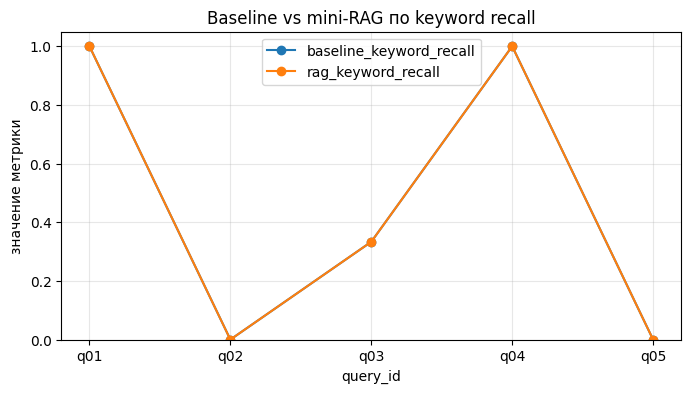

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["baseline_keyword_recall"],
    marker="o",
    label="baseline_keyword_recall",
)
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["rag_keyword_recall"],
    marker="o",
    label="rag_keyword_recall",
)
plt.ylim(0, 1.05)
plt.xlabel("query_id")
plt.ylabel("значение метрики")
plt.title("Baseline vs mini-RAG по keyword recall")
plt.grid(alpha=0.3)
plt.legend()
plt.show()



## 12. Разбор слабых мест и ошибок

Даже если mini-RAG выглядит лучше baseline, это не значит, что система стала «умной и надежной».  
Нужно посмотреть, где ответы всё ещё слабые.

**Как читать этот график.** На графике сравниваются `baseline_keyword_recall` (синяя линия) и `rag_keyword_recall` (оранжевая линия) по каждому запросу.

Ключевая закономерность, которую можно увидеть:

- Там, где ожидаемые ключевые слова **совпадают с лексикой запроса** (q01: «overlap» есть и в вопросе, и в ответе; q04: «гибридный поиск», «dense», «лексический» – в вопросе и в нужном предложении), обе системы могут достигать высокого recall, потому что TF-IDF уверенно выбирает нужное предложение.
- Там, где ответ **использует терминологию, которой нет в вопросе** (q02: «как оценивают?» → ожидаем `hit@k, recall@k, MRR`; q05: «зачем реранжировщик?» → ожидаем `пересортировывает, кандидатов`), обе системы дают recall ≈ 0: TF-IDF выбирает предложение, лексически похожее на **вопрос**, а не на **ответ**.

Это фундаментальное ограничение extractive-подхода: он умеет выбирать «похожее на запрос», а не «содержащее ответ». Разница между ними – именно та граница, за которой нужна настоящая LLM.


In [22]:
weak_cases = evaluation_df[
    evaluation_df["rag_keyword_recall"] < evaluation_df["rag_keyword_recall"].max()
].reset_index(drop=True)

display(weak_cases if len(weak_cases) > 0 else evaluation_df.head(0))

if len(weak_cases) == 0:
    print("На этом маленьком benchmark все ответы mini-RAG достигли одинакового keyword recall.")
else:
    print("Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.")


,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q02,Как оценивают качество retrieval?,doc_04,"doc_04, doc_08, doc_04",1,0.000000,0.000000,Качество retrieval нельзя оценивать только виз...,Качество retrieval нельзя оценивать только виз...
1,q03,Что делать после обновления базы знаний?,doc_05,"doc_05, doc_03, doc_07",1,0.333333,0.333333,После добавления новых документов база знаний ...,После добавления новых документов база знаний ...
2,q05,Зачем нужен реранжировщик после первичного ret...,doc_09,"doc_09, doc_08, doc_04",1,0.000000,0.000000,После первичного retrieval можно применять рер...,После первичного retrieval можно применять рер...


Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.


In [23]:
for _, row in weak_cases.iterrows():
    display(Markdown(f"### Слабый кейс: {row['query']}"))
    rag = mini_rag_answer(row["query"], artifacts=artifacts, top_k=3)
    display(Markdown(f"**Ответ mini-RAG:** {rag['answer']}"))
    display(rag["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])


### Слабый кейс: Как оценивают качество retrieval?

**Ответ mini-RAG:** Качество retrieval нельзя оценивать только визуально. Помимо текста, retrieval может учитывать метаданные: тип документа, дату, автора, подразделение или теги.

,rank,score,doc_id,title,chunk_text
0,1,0.717545,doc_04,Оценка качества retrieval,Качество retrieval нельзя оценивать только виз...
1,2,0.695651,doc_08,Метаданные и фильтрация,"Помимо текста, retrieval может учитывать метад..."
2,3,0.665814,doc_04,Оценка качества retrieval,retriever релевантный документ и насколько выс...


### Слабый кейс: Что делать после обновления базы знаний?

**Ответ mini-RAG:** После добавления новых документов база знаний должна быть переиндексирована.

,rank,score,doc_id,title,chunk_text
0,1,0.498571,doc_05,Обновление базы знаний,После добавления новых документов база знаний ...
1,2,0.236224,doc_03,Чанкинг и overlap,Чанкинг разбивает длинный документ на более ко...
2,3,0.203505,doc_07,Промпт с контекстом,на основании источников и возвращать указание ...


### Слабый кейс: Зачем нужен реранжировщик после первичного retrieval?

**Ответ mini-RAG:** После первичного retrieval можно применять реранжирование. Качество retrieval нельзя оценивать только визуально.

,rank,score,doc_id,title,chunk_text
0,1,0.673761,doc_09,Реранжирование результатов,После первичного retrieval можно применять рер...
1,2,0.579107,doc_08,Метаданные и фильтрация,"Помимо текста, retrieval может учитывать метад..."
2,3,0.543281,doc_04,Оценка качества retrieval,Качество retrieval нельзя оценивать только виз...


## 13. Что влияет на качество mini-RAG

На практике качество зависит не только от генератора, но и от всей цепочки:

- **состав базы знаний**;
- **чанкинг и overlap**;
- **модель эмбеддингов** или другой backend retrieval;
- **значение top-k**;
- **правила сборки контекста**;
- **способ генерации ответа**;
- **формат возврата источников**;
- **наличие реранжирования и фильтрации по метаданным**.

То есть RAG – это не «одна модель», а **система взаимосвязанных компонентов**.


## 14. Ограничения текущего учебного решения

Текущий mini-RAG полезен для обучения, но у него есть ограничения:

- генератор здесь **extractive**, а не полноценная LLM;
- автоматическая оценка по `keyword_recall` – очень грубая;
- корпус документов маленький и искусственно чистый;
- нет отдельного reranker;
- нет фильтрации по метаданным перед retrieval;
- нет контроля длины промпта и ограничений контекста для реальной LLM;
- нет production-механики: логирования запросов, кэширования, защиты от prompt injection и т.д.

Именно поэтому следующая тема курса логично продолжает эту:  
после mini-RAG мы переходим к **LLM, prompt engineering и адаптации моделей**.


## 15. Итоги

В этом ноутбуке мы собрали **полный учебный mini-RAG-контур**:

- построили retriever по чанкам;
- реализовали baseline без retrieval;
- собрали контекст из найденных фрагментов;
- сформировали ответ по контексту;
- вернули источники вместе с ответом;
- провели мини-оценку и разобрали слабые кейсы.

Главная мысль:  
**качество RAG определяется не только генератором, а всем пайплайном retrieval + context building + answer generation + source attribution.**


## Задания для самостоятельной работы

1. Замените текущую учебную базу знаний на собственный небольшой корпус из 8-15 документов по выбранной теме.
2. Сравните 2-3 варианта `chunk_size` и `overlap` и посмотрите, как меняется качество ответов.
3. Добавьте фильтрацию по метаданным перед retrieval.
4. Реализуйте простой reranking для top-k найденных чанков.
5. Замените extractive-генератор на небольшую генеративную модель и сравните качество.
6. Предложите собственный способ автоматической оценки качества mini-RAG помимо `keyword_recall`.
